Notes:
- Using Effective Rank to determine how much of the latent space is being used
- Prediciting for 1 frame yeilds very poor results for longer horizon tasks 
- Using a windowed approach and training on chained windows (i.e. the model eating its own output) loses fine grained accuracy but gains much more UNDERSTANDING of the physics governing the processes.
- STDev for V-JEPA is clearly skewed 
- From the PCA analysis, the model underestimates "speed" (step size) causing the indecies to desync. Change N_ROLL (i.e the number of training rollouts) by incrasing it to have the model accurately show the step size.

In [1]:
import torch
import torch.nn as nn 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from data import physics_process
from VJEPA import exponential_moving_average
from models import encoder, predictor
import contextlib, math, torch, torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import copy
from metrics import effective_rank, embedding_std, teacher_student_gap, rel_L1, rollout_error
from sklearn.decomposition import PCA

In [2]:
import imageio

In [3]:
frames, states = physics_process(32, 10, 3.0, 0.0, frames=120, dt=0.05)


In [2]:
import json, os
os.makedirs("episodes", exist_ok=True)
manifest = []

N_EPISODES = 300
for ep in range(N_EPISODES):
    rng = np.random.default_rng(ep)          #
    r  = rng.uniform(3, 8)
    x  = rng.uniform(r, 64 - r)
    y  = rng.uniform(r, 64 - r)
    vx = rng.uniform(-5, 5)
    vy = rng.uniform(-5, 5)

    frames, states = physics_process(x, y, vx, vy, r=r, frames=120, dt=0.05)

    path = f"episodes/ep_{ep:04d}.npz"
    np.savez_compressed(path, frames=frames, states=states,
                        radius=r, dt=0.05, seed=ep)
    manifest.append({"path": path, "radius": float(r), "seed": ep})

json.dump(manifest, open("episodes/manifest.json", "w"), indent=2)

In [3]:
# (July 25)
# 3 main functions of a custon PyTorch dataloader:
# init, len, getitem 
# Stack is the context frames it has (how many strating from t), w
# while k is the offset for the target frames, i.e. if the context
# is [t:t+stack], then the traget is [t+k:t+k+stack]
class BounceDataset(Dataset):
    def __init__(self, manifest_path, episode_ids, stack, k, n_roll=4):
        self.stack, self.k, self.n_roll = stack, k, n_roll
        manifest = json.load(open(manifest_path))

        self.frames, self.states, self.index = [], [], []
        for entry in manifest:
            if entry["seed"] not in episode_ids:
                continue
            d = np.load(entry["path"])
            f, s = d["frames"], d["states"]
            slot = len(self.frames)
            self.frames.append(f)
            self.states.append(s)
            T = f.shape[0]
            for t in range(T - stack - n_roll * k + 1):
                self.index.append((slot, t))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        slot, t = self.index[i]
        f, s = self.frames[slot], self.states[slot]

        ctx = f[t : t + self.stack]
        tgts = np.stack([f[t + n*self.k : t + n*self.k + self.stack]
                         for n in range(1, self.n_roll + 1)])

        ctx  = torch.from_numpy(ctx.astype(np.float32) / 255.0)
        tgts = torch.from_numpy(tgts.astype(np.float32) / 255.0)
        state = torch.from_numpy(s[t + self.stack - 1])
        return ctx, tgts, state

In [ ]:
manifest = json.load(open("episodes/manifest.json"))
rng = np.random.default_rng(0)

radius_test = {e["seed"] for e in manifest if 5.0 <= e["radius"] < 6.0}
rest = np.array([e["seed"] for e in manifest if e["seed"] not in radius_test])
rng.shuffle(rest)
n_val = int(0.15 * len(rest))
val_id, train_id = set(rest[:n_val]), set(rest[n_val:])

train_ds = BounceDataset("episodes/manifest.json", train_id, stack=8, k=2, n_roll=12) #(Aug 15) n_roll changed to 12
val_ds   = BounceDataset("episodes/manifest.json", val_id,   stack=8, k=2, n_roll=12)
test_ds  = BounceDataset("episodes/manifest.json", radius_test, stack=8, k=2, n_roll=12)

In [9]:
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True, num_workers=0) # DO NOT USE MORE WORKERS ON MAC or WINDOWS because for some reason Linux is the only one that uses fork (includes the memory of the previous code blocks run) system call when spawining child processes, 
val_loader   = DataLoader(val_ds, batch_size=512, shuffle=False)

In [10]:
# (July 25) Std-dev increasting montonically, becoming skewed (keep in mind for LeWorldModel)
x_encoder = encoder(in_channels=8).to("cuda")
y_encoder = copy.deepcopy(x_encoder).to("cuda")
y_encoder.requires_grad_(False)
M_START = 0.996
N_ROLL = 12 #(Aug 12) changing from 4 to 12
predictori = predictor().to("cuda")
opt = torch.optim.AdamW(
    list(x_encoder.parameters()) + list(predictori.parameters()),
    lr=1e-4, weight_decay=0.05)

metric_ctx, metric_tgts, _ = next(iter(val_loader))
metric_ctx, metric_tgts = metric_ctx.to("cuda"), metric_tgts.to("cuda")

total = 50 * len(train_loader)
step = 0
#(Aug 10) Its necessary to go beyond 15 epochs due to the training curve, interestingly around epoch 30, the single frame predictor bottoms out and overfits
#(Aug 12) Making it 50 epochs, will do fine tuning late
for epochs in range(50):
    x_encoder.train()
    predictori.train()
    y_encoder.eval() # EMA 
    for ctx, tgt, i in train_loader:
        ctx, tgts = ctx.to("cuda"), tgt.to("cuda")

        z = x_encoder(ctx)
        loss = 0.0
        for n in range(N_ROLL): #(July 26)Altering the training process for rolled dataset
            z = predictori(z)
            with torch.no_grad():
                zt = y_encoder(tgts[:, n]) # unroll N_ROLL times (i.e context = fames[a:b], target_0 = frames[a+k:b+k], target_n = frames[a+n*k:b+n*k])
            loss = loss + F.l1_loss(z, zt)
        loss = loss / N_ROLL
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(x_encoder.parameters()) + list(predictori.parameters()), 1.0)
        opt.step()
        m = 1 - (1-M_START) * (math.cos(math.pi * step / total) + 1 )/2
        exponential_moving_average(x_encoder, y_encoder, m)
        step += 1

        x_encoder.eval(); predictori.eval()
    with torch.no_grad():
        z = x_encoder(metric_ctx)
        z0 = z
        per_step, ident = [], []
        for n in range(N_ROLL):
            z = predictori(z)
            zt = y_encoder(metric_tgts[:, n])
            per_step.append(rel_L1(z, zt))
            ident.append(rel_L1(z0, zt))
        msg = "  ".join(f"n{n+1} {r:.3f}/{i:.3f}" for n, (r, i) in enumerate(zip(per_step, ident)))
        print(f"ep {epochs:3d} | {msg} | erank {effective_rank(z0):.1f} "
              f"| std {embedding_std(z0):.3f} | gap {teacher_student_gap(x_encoder, y_encoder):.4f}") #(Aug 10)n1,n2,n3,n4 shows the model pred chained error/single frame pred error for each horizon.  

ep   0 | n1 0.526/3.349  n2 0.689/3.356  n3 0.707/3.370  n4 0.709/3.389  n5 0.711/3.411  n6 0.713/3.434  n7 0.715/3.456  n8 0.717/3.476  n9 0.719/3.494  n10 0.721/3.510  n11 0.722/3.522  n12 0.724/3.535 | erank 9.2 | std 1.635 | gap 0.0717
ep   1 | n1 0.360/2.197  n2 0.598/2.209  n3 0.676/2.236  n4 0.695/2.273  n5 0.700/2.315  n6 0.703/2.360  n7 0.705/2.403  n8 0.707/2.443  n9 0.708/2.479  n10 0.710/2.510  n11 0.712/2.535  n12 0.715/2.557 | erank 9.1 | std 2.193 | gap 0.0762
ep   2 | n1 0.380/1.128  n2 0.481/1.133  n3 0.542/1.164  n4 0.573/1.215  n5 0.593/1.276  n6 0.610/1.340  n7 0.626/1.403  n8 0.641/1.460  n9 0.657/1.510  n10 0.672/1.554  n11 0.688/1.590  n12 0.702/1.620 | erank 10.3 | std 2.129 | gap 0.0766
ep   3 | n1 0.390/0.654  n2 0.425/0.641  n3 0.455/0.671  n4 0.477/0.726  n5 0.495/0.793  n6 0.512/0.864  n7 0.530/0.934  n8 0.550/0.999  n9 0.570/1.057  n10 0.592/1.106  n11 0.614/1.148  n12 0.636/1.182 | erank 10.3 | std 1.944 | gap 0.0797
ep   4 | n1 0.404/0.446  n2 0.405/0.42

0.6974803
0.2361405
n= 0  true  25.873  imag  25.873  ratio 1.000
n= 1  true  25.621  imag  23.735  ratio 0.926
n= 2  true  24.496  imag  23.067  ratio 0.942
n= 3  true  22.945  imag  22.286  ratio 0.971
n= 4  true  20.712  imag  21.245  ratio 1.026
n= 5  true  18.823  imag  20.024  ratio 1.064
n= 6  true  17.643  imag  18.754  ratio 1.063
n= 7  true  17.422  imag  17.625  ratio 1.012
n= 8  true  16.492  imag  16.887  ratio 1.024
n= 9  true  15.642  imag  16.768  ratio 1.072
n=10  true  14.630  imag  17.329  ratio 1.184
n=11  true  14.425  imag  18.385  ratio 1.275
n=12  true  15.193  imag  19.543  ratio 1.286
n=13  true  17.058  imag  20.562  ratio 1.205
n=14  true  20.047  imag  21.439  ratio 1.069
n=15  true  22.197  imag  22.144  ratio 0.998
n=16  true  23.685  imag  22.765  ratio 0.961
n=17  true  24.521  imag  23.390  ratio 0.954
n=18  true  25.805  imag  24.104  ratio 0.934
n=19  true  27.463  imag  25.004  ratio 0.910
n=20  true  28.554  imag  25.989  ratio 0.910
n=21  true  28

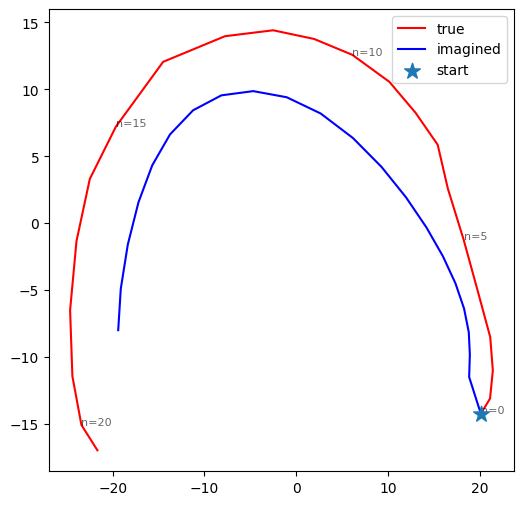

In [11]:
# PCA of learned trajectory vs real trajectory 
@torch.no_grad()
def latent_traj(x_enc, pred, frames, stack, k, n_steps):
    idxs = [n*k for n in range(n_steps + 1)] #starting indexes for each ep
    tru = torch.cat([x_enc(frames[s:s+stack].unsqueeze(0)) for s in idxs])

    imagined = x_enc(frames[0:stack].unsqueeze(0)) #initial stack
    imag = [imagined]
    for _ in range(n_steps):
        imagined = pred(imagined)
        imag.append(imagined)
    imag = torch.cat(imag)
    return tru.cpu().numpy(), imag.cpu().numpy()

x_encoder.eval(), predictori.eval()
#helper to load an episode
def load_episode(manifest, seed, device="cuda"):
    entry = next(e for e in manifest if e["seed"] == seed)
    d = np.load(entry["path"])
    return (torch.from_numpy(d["frames"].astype(np.float32) / 255.0).to(device),
            d["states"])
frames, states = load_episode(manifest, sorted(val_id)[0])
true, imag = latent_traj(x_encoder, predictori, frames, 8, 2, n_steps=21) #8 is the STACK and 2 is K 

pca = PCA(n_components=2).fit(true) #pls have 2d be >70%

T2D, I2D = pca.transform(true), pca.transform(imag)

print(pca.explained_variance_ratio_[0]) # x_dir
print(pca.explained_variance_ratio_[1]) # y_dir

mu = true.mean(0)
true_norm = np.linalg.norm(true - mu, axis=1)
imag_norm = np.linalg.norm(imag - mu, axis=1)

for n, (t, i) in enumerate(zip(true_norm, imag_norm)):
    print(f"n={n:2d}  true {t:7.3f}  imag {i:7.3f}  ratio {i/t:.3f}")
#(Aug 12) The ratio is within acceptable limits, between 0.99 and 1.1
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(T2D[:, 0], T2D[:, 1], 'r', label='true')
ax.plot(I2D[:, 0], I2D[:, 1], 'b', label='imagined')
ax.scatter(*T2D[0], s=140, marker='*', zorder=5, label='start')
for i in range(0, 21, 5):
    ax.annotate(f'n={i}', T2D[i], fontsize=8, alpha=0.6)
ax.legend()
plt.show()




                   


In [12]:
from scipy.spatial.distance import cdist

D = cdist(imag, true)
# (Aug 12) Find the "closest" idx
print(D.argmin(axis=1)) # (Aug 12) The index is lagging but its predicting the actual route well.
# i.e its underestimated the speed


[ 0  2  2  3  3  4  4  5  7  7 10 10 12 12 13 14 14 15 17 18 18 18]


In [13]:
#(Aug 12) Checking the actual diff
true_steps = np.linalg.norm(np.diff(true, axis=0), axis=1)
imag_steps = np.linalg.norm(np.diff(imag, axis=0), axis=1)
print(imag_steps / true_steps)
#(Aug 12) the actual diff is less than 1, hence its a pred error, not an extrap error

[3.3469582  0.8871794  0.63848686 0.5358456  0.5163868  0.65212727
 0.8489414  0.9877197  1.0267506  0.81015736 0.8503783  0.7961582
 0.6423569  0.5184796  0.5118752  0.76887554 0.71049803 0.61232615
 0.661982   0.8191913  0.8095199 ]


(Aug 12) It seems like the learned model is getting the right physics however, underestimating the magnitude (however this could be a projection issue as we cover 80%)

Testing w 1 frame

In [ ]:
@torch.no_grad()
def identity_rollout(x_enc, y_enc, frames, t0, steps, stack, k):
    z = x_enc(frames[t0:t0+stack].unsqueeze(0))
    out = []
    for n in range(1, steps+1):
        s = t0 + n*k
        zt = y_enc(frames[s:s+stack].unsqueeze(0))
        out.append(rel_L1(z, zt))
    return out

x_encoder.eval(); y_encoder.eval(); predictori.eval()

STACK, K, STEPS = 8, 2, 8
seed = sorted(radius_test)[0]
entry = next(e for e in manifest if e["seed"] == seed)
d = np.load(entry["path"])
frames = torch.from_numpy(d["frames"].astype(np.float32) / 255.0).to("cuda")
states = d["states"]

model = rollout_error(x_encoder, y_encoder, predictori, frames, 30, STEPS, STACK, K)
ident = identity_rollout(x_encoder, y_encoder, frames, 30, STEPS, STACK, K)
for n, (m, i) in enumerate(zip(model, ident), 1):
        print(f"  n={n:2d} (Δt={n*K:2d})  model {m:.3f}  identity {i:.3f}  ratio {i/m:.1f}×")

#(July 26)The issue is that its not effective beyond 2 datetime steps, idk why
#(Aug 10)Now I know, it is due to the training process

  n= 1 (Δt= 2)  model 0.043  identity 0.423  ratio 9.9×
  n= 2 (Δt= 4)  model 0.292  identity 0.527  ratio 1.8×
  n= 3 (Δt= 6)  model 0.497  identity 0.723  ratio 1.5×
  n= 4 (Δt= 8)  model 0.631  identity 0.892  ratio 1.4×
  n= 5 (Δt=10)  model 0.734  identity 1.024  ratio 1.4×
  n= 6 (Δt=12)  model 0.813  identity 1.103  ratio 1.4×
  n= 7 (Δt=14)  model 0.882  identity 1.221  ratio 1.4×
  n= 8 (Δt=16)  model 0.929  identity 1.325  ratio 1.4×


In [ ]:
# Verifying 
@torch.no_grad()
def rollout_variants(x_enc, y_enc, pred, frames, t0, steps, stack, k):
    def enc_x(s): return x_enc(frames[s:s+stack].unsqueeze(0))
    def enc_y(s): return y_enc(frames[s:s+stack].unsqueeze(0))

    # A: current — x-space context, chained
    zA = enc_x(t0)
    # B: y-space context, chained  (removes the x→y offset at step 1)
    zB = enc_y(t0)

    rows = []
    for n in range(1, steps + 1):
        s = t0 + n * k
        zt = enc_y(s)

        zA = pred(zA)
        zB = pred(zB)

        # C: teacher-forced — re-encode the TRUE frame each step, predict once
        zC = pred(enc_x(s - k))

        # identity baseline
        ident = rel_L1(enc_x(t0), zt)

        rows.append((n, rel_L1(zA, zt), rel_L1(zB, zt), rel_L1(zC, zt), ident))
    return rows


x_encoder.eval(); y_encoder.eval(); predictori.eval()
# (July 26)
# C is the learned encoder embedding of the world, since its constant (roughly), it learned the dynamics of the world just fine
# A is when its being fed its own output, and its struggling at reconciling its own output, snowballing errors beyond comprehension
# Its actually worse at longer timesteps then just having 2 encoders
for n, a, b, c, i in rollout_variants(x_encoder, y_encoder, predictori,
                                      frames, 0, STEPS, STACK, K):
    print(f"{n:3d} {n*K:3d} {a:10.3f} {b:10.3f} {c:9.3f} {i:7.3f}")
# Thus we will create 4 windows with dt=2 difference between each 

  1   2      0.072      0.291     0.072   0.442
  2   4      0.334      0.496     0.062   0.423
  3   6      0.514      0.628     0.038   0.428
  4   8      0.638      0.723     0.034   0.457
  5  10      0.731      0.797     0.043   0.536
  6  12      0.799      0.854     0.039   0.632
  7  14      0.854      0.903     0.040   0.741
  8  16      0.903      0.946     0.049   0.869
